# ***神经网络思想实现Logistic回归***

# 0. 要解决的问题

案例描述：将学习如何建立逻辑回归分类器用来识别猫。

note：  
1. 这项作业将引导你逐步了解神经网络的思维方式，同时磨练你对深度学习的直觉。
2. 除非指令中明确要求使用，否则请勿在代码中使用循环（for / while）。 

建立学习算法的一般架构，包括：
1. 初始化参数
2. 计算损失函数及其梯度
3. 使用优化算法（梯度下降）

这项作业按正确的顺序将以上所有三个功能集成到一个主模型上。

# 1. 导入包

① numpy 是Python科学计算的基本包。

② h5py是一个常用的包，可以处理存储为H5文件格式的数据集。

③ matplotlib是一个著名的Python图形库。

④ lr_utils是一个加载资料包里面的数据的简单功能的库。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy
from PIL import Image
from scipy import ndimage
from lr_utils import load_dataset
import scipy.misc

%matplotlib inline

C:\Users\YYZ\AppData\Local\Temp\ipykernel_28536\704997144.py:8: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc


# 2. 导入数据集

① 问题说明：你将获得一个包含以下内容的数据集（"data.h5"）：
1. 标记为cat（y = 1）或非cat（y = 0）的m_train训练图像集
2. 标记为cat或non-cat的m_test测试图像集
3. 图像维度为（num_px，num_px，3），其中3表示3个通道（RGB）。因此，每个图像都是正方形（高度= num_px）和（宽度= num_px）。

首先通过运行以下代码来加载数据。

note：我们在图像数据集（训练和测试）的末尾添加了"\_orig"，以便对其进行预处理。 预处理后，我们将得到train_set_x和test_set_x（标签train_set_y和test_set_y不需要任何预处理）。

In [2]:
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()
# load_dataset是lr_utils.py中的函数，这句话相当于给这个函数的返回值命名

② 解释一下上面的load_dataset() 返回的值的含义：

1. train_set_x_orig ：保存的是训练集里面的图像数据（本训练集有209张64x64的图像）。
2. train_set_y_orig ：保存的是训练集的图像对应的分类值（【0 | 1】，0表示不是猫，1表示是猫）。
3. test_set_x_orig ：保存的是测试集里面的图像数据（本测试集有50张64x64的图像）。
4. test_set_y_orig ： 保存的是测试集的图像对应的分类值（【0 | 1】，0表示不是猫，1表示是猫）。
5. classes ： 保存的是以bytes类型保存的两个字符串数据，数据为：[b’non-cat’ b’cat’]。

# 3. 查看图片数据

① train_set_x_orig和test_set_x_orig的每一行都是代表图像的数组。 你可以通过运行以下代码来可视化示例。 还可以随意更改index值并重新运行以查看其他图像。

y = [0], it's a 'non-cat' picture.
【使用np.squeeze：0，不使用np.squeeze： [0]】


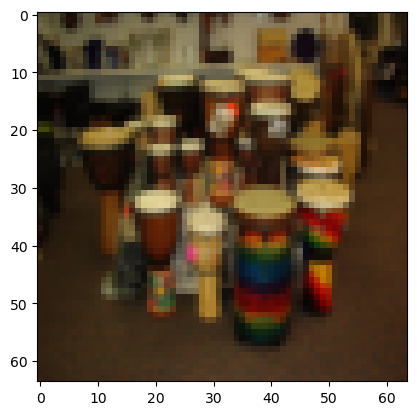

In [3]:
# Example of a picture
# 打印出当前的训练标签值
# 使用np.squeeze的目的是压缩维度，【未压缩】train_set_y[:,index]的值为[1] , 【压缩后】np.squeeze(train_set_y[:,index])的值为1
# print("【使用np.squeeze：" + str(np.squeeze(train_set_y[:,index])) + "，不使用np.squeeze： " + str(train_set_y[:,index]) + "】")
# 只有压缩后的值才能进行解码操作
index = 5
plt.imshow(train_set_x_orig[index])
print(
    "y = "
    + str(train_set_y[:, index])
    + ", it's a '"
    + classes[np.squeeze(train_set_y[:, index])].decode("utf-8")
    + "' picture."
)
print(
    "【使用np.squeeze："
    + str(np.squeeze(train_set_y[:, index]))
    + "，不使用np.squeeze： "
    + str(train_set_y[:, index])
    + "】"
)

# 4. 查看向量尺寸

① 深度学习中的许多报错都来自于矩阵/向量尺寸不匹配。 如果你可以保持矩阵/向量的尺寸不变，那么将消除大多错误。

练习： 查找以下各项的值：
1. m_train（训练集示例数量）
2. m_test（测试集示例数量）
3. num_px（=训练图像的高度=训练图像的宽度）

note："train_set_x_orig" 是一个维度为（m_train，num_px，num_py，3）的numpy数组。 例如，你可以通过编写“ train_set_x_orig.shape [0]”来访问“ m_train”。

In [4]:
### START CODE HERE ### (≈ 3 lines of code)
m_train = train_set_x_orig.shape[0]
m_test = train_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[1]
num_py = train_set_x_orig.shape[2]
### END CODE HERE ###

# #看一看 加载的东西的具体情况
print("Number of training examples: m_train = " + str(m_train))
print("Number of testing examples: m_test = " + str(m_test))
print("Height of each image: num_px = " + str(num_px))
print("Each image is of size: (" + str(num_px) + ", " + str(num_py) + ", 3)")
print("train_set_x shape: " + str(train_set_x_orig.shape))
# test_set_y_orig 为局部变量，返回赋给 train_set_y 了
print("train_set_y shape: " + str(train_set_y.shape))
print("test_set_x shape: " + str(test_set_x_orig.shape))
print("test_set_y shape: " + str(test_set_y.shape))

Number of training examples: m_train = 209
Number of testing examples: m_test = 209
Height of each image: num_px = 64
Each image is of size: (64, 64, 3)
train_set_x shape: (209, 64, 64, 3)
train_set_y shape: (1, 209)
test_set_x shape: (50, 64, 64, 3)
test_set_y shape: (1, 50)


# 5. 重塑维度

① 为了方便起见，你现在应该以维度(num_px * num_px * 3, 1)的numpy数组重塑维度（num_px，num_px，3）的图像。 

② 此后，我们的训练（和测试）数据集是一个numpy数组，其中每列代表一个展平的图像。 应该有m_train（和m_test）列。

<strong>练习</strong>： 重塑训练和测试数据集，以便将大小（num_px，num_px，3）的图像展平为单个形状的向量(num_px × num_px × 3, 1)。

③ 当你想将维度为（a，b，c，d）的矩阵X展平为形状为(b * c * d, a)的矩阵X_flatten时的一个技巧是：X_flatten = X.reshape（X.shape [0]，-1）.T     ＃ 其中X.T是X的转置矩阵

In [5]:
# Reshape the training and test examples

### START CODE HERE ### (≈ 2 lines of code)
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T
### END CODE HERE ###

① 这一段意思是指把数组变为209行的矩阵（因为训练集里有209张图片），但是我懒得算列有多少，于是我就用-1告诉程序你帮我算，最后程序算出来时12288列。

② 我再最后用一个T表示转置，这就变成了12288行，209列。

③ 测试集亦如此。

In [6]:
# 看看降维之后的情况是怎么样的
print("训练集降维最后的维度: " + str(train_set_x_flatten.shape))
print("训练集_标签的维数: " + str(train_set_y.shape))
print("测试集降维之后的维度: " + str(test_set_x_flatten.shape))
print("测试集_标签的维数: " + str(test_set_y.shape))
print("重塑后的检查维度: " + str(train_set_x_flatten[0:5, 0]))

训练集降维最后的维度: (12288, 209)
训练集_标签的维数: (1, 209)
测试集降维之后的维度: (12288, 50)
测试集_标签的维数: (1, 50)
重塑后的检查维度: [17 31 56 22 33]


# 6.标准化数据集

① 为了表示彩色图像，必须为每个像素指定红色，绿色和蓝色通道（RGB），因此像素值实际上是从0到255范围内的三个数字的向量。

② 机器学习中一个常见的预处理步骤是**对数据集进行居中和标准化**，这意味着可以减去每个示例中整个numpy数组的平均值，然后将每个示例除以整个numpy数组的标准偏差。

③ 但对于图片数据集，它更简单，更方便，几乎可以将数据集的每一行除以255（像素通道的最大值），因为在RGB中不存在比255大的数据，所以我们可以放心的除以255，让标准化的数据位于[0,1]之间。

④ 现在标准化我们的数据集：

In [7]:
train_set_x = train_set_x_flatten/255
test_set_x = test_set_x_flatten/255


现在是时候设计一种简单的算法来区分猫图像和非猫图像了。

你将使用神经网络思维方式建立Logistic回归。 下图说明了为什么“逻辑回归实际上是一个非常简单的神经网络！”

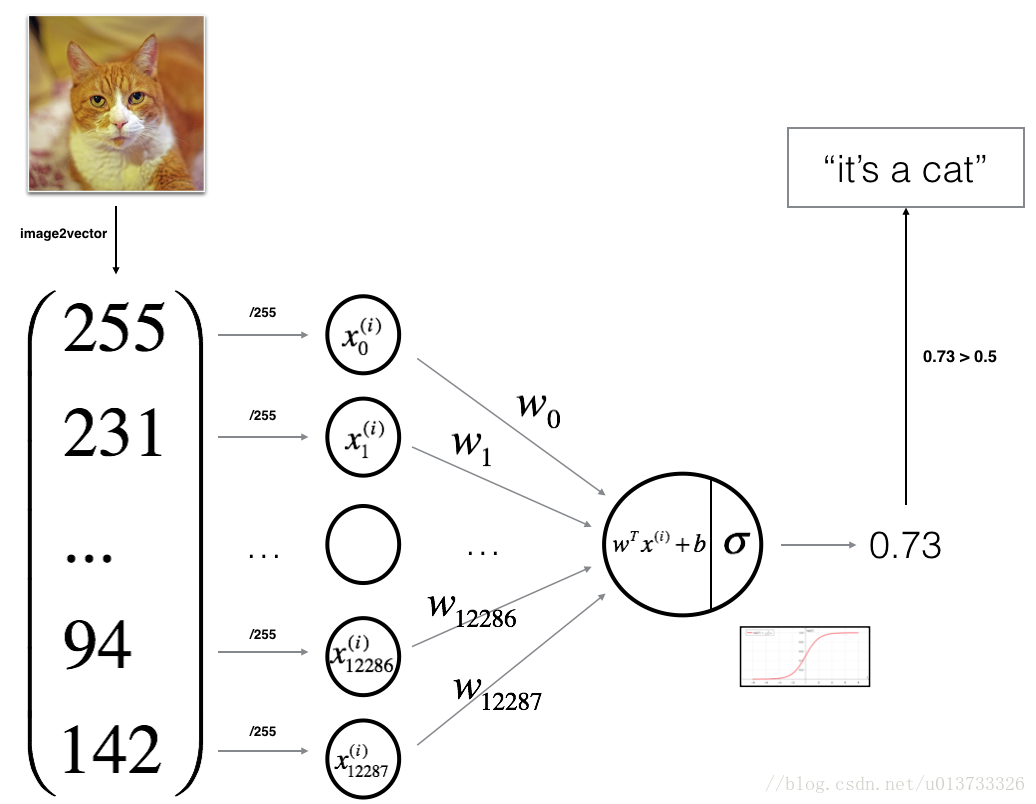

**关键步骤：**  
在本练习中，你将执行以下步骤：  
- 初始化模型参数  
- 通过最小化损失来学习模型的参数
- 使用学习到的参数进行预测（在测试集上）
- 分析结果并得出结论

# 7. 预处理数据集

① 预处理数据集的常见步骤是：

1. 找出数据的尺寸和维度（m_train，m_test，num_px等）
2. 重塑数据集，以使每个示例都是大小为（num_px * num_px * 3，1）的向量
3. “标准化”数据

# 8. 建立神经网络

## 8.1 建立神经网络数学模型

① 现在总算是把我们加载的数据弄完了，我们现在开始构建神经网络。

② 对于 $$x^{(i)}$$
$$z^{(i)} = w^T x^{(i)} + b \tag{1}$$
$$\hat{y}^{(i)} = a^{(i)} = sigmoid(z^{(i)})\tag{2}$$
$$\mathcal{L}(a^{(i)}, y^{(i)}) =  - y^{(i)}  \log(a^{(i)}) - (1-y^{(i)} )  \log(1-a^{(i)})\tag{3}$$

③ 然后通过对所有训练样例求和来计算成本：

$$J = \frac{1}{m} \sum_{i=1}^m \mathcal{L}(a^{(i)}, y^{(i)})\tag{4}$$

## 8.2 建立神经网络主要步骤

① 建立神经网络的主要步骤是：

1. 定义模型结构（例如输入特征的数量）
2. 初始化模型的参数
3. 循环：
 - 3.1 计算当前损失（正向传播）
 - 3.2 计算当前梯度（反向传播）
 - 3.3 更新参数（梯度下降）

## 8.3 建立神经网络各个部分

### 8.3.1 建立sigmoid()函数

① 计算$sigmoid( w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$去预测，需要使用np.exp（）。

In [8]:
def sigmoid(z):
    """
    参数：
        z  - 任何大小的标量或numpy数组。
    
    返回：
        s  -  sigmoid（z）
    """
    
    s = 1 / (1 + np.exp(-z))    
    return s

② 测试一下sigmoid()，检查一下是否符合我们所需要的条件。

In [9]:
# 测试一下 sigmoid 函数
print("====================测试sigmoid====================")
print ("sigmoid(0) = " + str(sigmoid(0)))
print ("sigmoid(9.2) = " + str(sigmoid(9.2))) 
print ("sigmoid([0, 2]) = " + str(sigmoid(np.array([0,2]))))

====================测试sigmoid====================
sigmoid(0) = 0.5
sigmoid(9.2) = 0.9998989708060922
sigmoid([0, 2]) = [0.5        0.88079708]


### 8.3.2 建立initialize()函数

练习：在下面的单元格中实现参数初始化。
1. 你必须将w初始化为零的向量。
2. 如果你不知道要使用什么numpy函数，请在Numpy库的文档中查找np.zeros()。

***np.zeros()***  

**numpy.zeros(shape, dtype=float, order='C')**  
- **shape**：数组的形状，可以是一个整数或一个整数元组。例如，(2, 3) 表示一个 2 行 3 列的二维数组。

- **dtype**：数组的数据类型，可选参数，默认是 float。其他可选类型包括 int、str 等。

- **order**：可选参数，表示数组在内存中的存储顺序。'C' 表示按行存储（C-style），'F' 表示按列存储（Fortran-style），默认是 'C'。

In [10]:
def initialize_with_zeros(dim):
    """
    此函数为w创建一个维度为（dim，1）的0向量，并将b初始化为0。

    参数：
        dim  - 我们想要的w矢量的大小（或者这种情况下的参数数量）

    返回：
        w  - 维度为（dim，1）的初始化向量。
        b  - 初始化的标量（对应于偏差）
    """

    ### START CODE HERE ### (≈ 1 line of code)
    w = np.zeros((dim,1))
    b = 0
    ### END CODE HERE ###

    # 使用断言来确保我要的数据是正确的
    # w 的维度是 (dim,1)
    assert w.shape == (dim, 1)
    # b 的类型是 float 或者是 int
    assert isinstance(b, float) or isinstance(b, int)

    return w, b


dim = 2
w, b = initialize_with_zeros(dim)
print("w = " + str(w))
print("b = " + str(b))

w = [[0.]
 [0.]]
b = 0


### 8.3.3 建立propagate()函数

① 初始化参数的函数已经构建好了，现在就可以执行“前向”和“后向”传播来学习参数。

② 我们现在要实现函数propagate()来计算损失函数及其梯度。

③ 正向传播：
1. 获得X
2. 计算$A = \sigma(w^T X + b) = (a^{(0)}, a^{(1)}, ..., a^{(m-1)}, a^{(m)})$
3. 计算损失函数：$J = -\frac{1}{m}\sum_{i=1}^{m}y^{(i)}\log(a^{(i)})+(1-y^{(i)})\log(1-a^{(i)})$

④ 计算梯度，你将要使用到以下两个公式：
$$\frac{\partial J}{\partial w} = \frac{1}{m}X(A-Y)^T\tag{5}$$
$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^m (a^{(i)}-y^{(i)})\tag{6}$$

In [11]:
def propagate(w, b, X, Y):
    """
    实现前向和后向传播的传播函数，计算成本函数及其梯度。
    参数：
        w  - 权重，大小不等的数组（num_px * num_px * 3，1）
        b  - 偏差，一个标量
        X  - 矩阵类型为（num_px * num_px * 3，训练数量）
        Y  - 真正的“标签”矢量（如果非猫则为0，如果是猫则为1），矩阵维度为(1,训练数据数量)

    返回：
        cost- 逻辑回归的负对数似然成本
        dw  - 相对于w的损失梯度，因此与w相同的形状
        db  - 相对于b的损失梯度，因此与b的形状相同
    """

    m = X.shape[1]

    # FORWARD PROPAGATION (FROM X TO COST)
    ### START CODE HERE ### (≈ 2 lines of code)
    A = sigmoid(np.dot(w.T, X) + b)  # compute activation
    cost = -1 / m * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))  # compute cost
    ### END CODE HERE ###

    # BACKWARD PROPAGATION (TO FIND GRAD)
    ### START CODE HERE ### (≈ 2 lines of code)
    dw = 1 / m * np.dot(X, (A - Y).T)
    db = 1 / m * np.sum(A - Y)  ### END CODE HERE ###

    # 使用断言确保我的数据是正确的
    assert dw.shape == w.shape
    assert db.dtype == float
    cost = np.squeeze(cost)
    assert cost.shape == ()

    # 创建一个字典，把 dw 和 db 保存起来。
    grads = {"dw": dw, "db": db}

    return grads, cost

In [12]:
# 测试一下 propagate 函数
print("====================测试propagate====================")
w, b, X, Y = np.array([[1],[2]]), 2, np.array([[1,2],[3,4]]), np.array([[1,0]])
grads, cost = propagate(w, b, X, Y)
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("cost = " + str(cost))

====================测试propagate====================
dw = [[0.99993216]
 [1.99980262]]
db = 0.49993523062470574
cost = 6.000064773192205


### 8.3.4 建立optimize()函数

① 现在，我要使用渐变下降更新参数。

② 目标是通过最小化成本函数$J$来学习$w$和$b$。

③ 对于参数$\theta$，更新规则是$ \theta = \theta - \alpha \text{ } d\theta$，其中$\alpha$是学习率。

In [13]:
def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost=False):
    """
    此函数通过运行梯度下降算法来优化w和b

    参数：
        w  - 权重，大小不等的数组（num_px * num_px * 3，1）
        b  - 偏差，一个标量
        X  - 维度为（num_px * num_px * 3，训练数据的数量）的数组。
        Y  - 真正的“标签”矢量（如果非猫则为0，如果是猫则为1），矩阵维度为(1,训练数据的数量)
        num_iterations  - 优化循环的迭代次数
        learning_rate  - 梯度下降更新规则的学习率
        print_cost  - 每100步打印一次损失值

    返回：
        params  - 包含权重w和偏差b的字典
        grads  - 包含权重和偏差相对于成本函数的梯度的字典
        成本 - 优化期间计算的所有成本列表，将用于绘制学习曲线。

    提示：
    我们需要写下两个步骤并遍历它们：
        1）计算当前参数的成本和梯度，使用propagate（）。
        2）使用w和b的梯度下降法则更新参数。
    """

    costs = []

    for i in range(num_iterations):

        # Cost and gradient calculation (≈ 1-4 lines of code)
        ### START CODE HERE ###
        grads, cost = propagate(w, b, X, Y)
        ### END CODE HERE ###

        # Retrieve derivatives from grads
        dw = grads["dw"]
        db = grads["db"]

        # update rule (≈ 2 lines of code)
        ### START CODE HERE ###
        w = w - learning_rate * dw
        b = b - learning_rate * db
        ### END CODE HERE ###

        # 记录成本
        if i % 100 == 0:
            costs.append(cost)

        # 每 100 次训练 打印成本
        if print_cost and i % 100 == 0:
            print("Cost after iteration %i: %f" % (i, cost))

    params = {"w": w, "b": b}

    grads = {"dw": dw, "db": db}

    return params, grads, costs

In [14]:
#测试一下 optimize 函数
print("====================测试optimize====================")
params, grads, costs = optimize(w, b, X, Y, num_iterations= 100, learning_rate = 0.009, print_cost = False)
print ("w = " + str(params["w"]))
print ("b = " + str(params["b"]))
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print(costs)

====================测试optimize====================
w = [[0.1124579 ]
 [0.23106775]]
b = 1.5593049248448891
dw = [[0.90158428]
 [1.76250842]]
db = 0.4304620716786828
[np.float64(6.000064773192205)]


### 8.3.5 建立predict()函数

① optimize函数会输出已学习的w和b的值，我们可以使用w和b来预测数据集X的标签。

② 现在我们要实现预测函数predict（）。计算预测有两个步骤：
1. 计算$\hat{Y} = A = \sigma(w^T X + b)$
2. 将a的项转换为0（如果激活<= 0.5）或1（如果激活> 0.5），并将预测结果存储在向量“ Y_prediction”中。

In [15]:
def predict(w, b, X):
    """
    使用学习逻辑回归参数 logistic(w，b) 预测标签是0还是1，

    参数：
        w  - 权重，大小不等的数组（num_px * num_px * 3，1）
        b  - 偏差，一个标量
        X  - 维度为（num_px * num_px * 3，训练数据的数量）的数据

    返回：
        Y_prediction  - 包含X中所有图片的所有预测【0 | 1】的一个numpy数组（向量）

    """

    # 图片的数量
    m = X.shape[1]
    Y_prediction = np.zeros((1, m))
    w = w.reshape(X.shape[0], 1)

    # 预测猫在图片中出现的概率
    ### START CODE HERE ### (≈ 1 line of code)
    A = sigmoid(np.dot(w.T, X) + b)
    ### END CODE HERE ###

    for i in range(A.shape[1]):
        # 将概率 a[0，i] 转换为实际预测 p[0，i]
        ### START CODE HERE ### (≈ 4 lines of code)
        Y_prediction[0, i] = 1 if A[0, i] > 0.5 else 0
        ### END CODE HERE ###

    # 使用断言
    assert Y_prediction.shape == (1, m)

    return Y_prediction

In [16]:
# 测试一下 predict 函数
print("====================测试predict====================")
w, b, X, Y = np.array([[1], [2]]), 2, np.array([[1,2], [3,4]]), np.array([[1, 0]])
print("predictions = " + str(predict(w, b, X)))

====================测试predict====================
predictions = [[1. 1.]]


# 9. 功能合并模型中

## 9.1 搭建模型

① 就目前而言，我们基本上把所有的东西都做完了，现在我们要把这些函数统统整合到一个model()函数中，届时只需要调用一个model()就基本上完成所有的事了。

② 将所有构件（在上一部分中实现的功能）以正确的顺序放在一起，从而得到整体的模型结构。

In [17]:
def model(
    X_train,
    Y_train,
    X_test,
    Y_test,
    num_iterations=2000,
    learning_rate=0.5,
    print_cost=False,
):
    """
    通过调用之前实现的函数来构建逻辑回归模型

    参数：
        X_train  - numpy的数组,维度为（num_px * num_px * 3，m_train）的训练集
        Y_train  - numpy的数组,维度为（1，m_train）（矢量）的训练标签集
        X_test   - numpy的数组,维度为（num_px * num_px * 3，m_test）的测试集
        Y_test   - numpy的数组,维度为（1，m_test）的（向量）的测试标签集
        num_iterations  - 表示用于优化参数的迭代次数的超参数
        learning_rate  - 表示optimize（）更新规则中使用的学习速率的超参数
        print_cost  - 设置为true以每100次迭代打印成本

    返回：
        d  - 包含有关模型信息的字典。
    """

    ### START CODE HERE ###

    # initialize parameters with zeros (≈ 1 line of code)
    w, b = initialize_with_zeros(X_train.shape[0])
    # Gradient descent (≈ 1 line of code)

    parameters, grads, costs = optimize(
        w, b, X_train, Y_train, num_iterations, learning_rate, print_cost
    )
    # Retrieve parameters w and b from dictionary "parameters"
    w = parameters["w"]
    b = parameters["b"]

    # Predict test/train set examples (≈ 2 lines of code)

    ### END CODE HERE ###
    Y_prediction_test = predict(w,b,X_test)
    Y_prediction_train = predict(w,b,X_train)
    # Print train/test Errors
    print(
        "train accuracy: {} %".format(
            100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100
        )
    )
    print(
        "test accuracy: {} %".format(
            100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100
        )
    )

    d = {
        "costs": costs,
        "Y_prediction_test": Y_prediction_test,
        "Y_prediction_train": Y_prediction_train,
        "w": w,
        "b": b,
        "learning_rate": learning_rate,
        "num_iterations": num_iterations,
    }

    return d

## 9.2 训练模型

① 把整个model构建好之后我们这就算是正式的实际测试了，我们这就来实际跑一下。

In [28]:
print("====================测试model====================")
# 这里加载的是真实的数据
d = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations = 10000, learning_rate = 0.005, print_cost = True)             

====================测试model====================
Cost after iteration 0: 0.693147
Cost after iteration 100: 0.584508
Cost after iteration 200: 0.466949
Cost after iteration 300: 0.376007
Cost after iteration 400: 0.331463
Cost after iteration 500: 0.303273
Cost after iteration 600: 0.279880
Cost after iteration 700: 0.260042
Cost after iteration 800: 0.242941
Cost after iteration 900: 0.228004
Cost after iteration 1000: 0.214820
Cost after iteration 1100: 0.203078
Cost after iteration 1200: 0.192544
Cost after iteration 1300: 0.183033
Cost after iteration 1400: 0.174399
Cost after iteration 1500: 0.166521
Cost after iteration 1600: 0.159305
Cost after iteration 1700: 0.152667
Cost after iteration 1800: 0.146542
Cost after iteration 1900: 0.140872
Cost after iteration 2000: 0.135608
Cost after iteration 2100: 0.130708
Cost after iteration 2200: 0.126137
Cost after iteration 2300: 0.121861
Cost after iteration 2400: 0.117855
Cost after iteration 2500: 0.114093
Cost after iteration 2600: 0

② 训练准确性接近100％。这是一个很好的情况。

③ 测试误差为70％。考虑到我们使用的数据集很小，并且逻辑回归是线性分类器，对于这个简单的模型来说，这实际上还不错。下周你将建立一个更好的分类器！

④ 我们更改一下学习率和迭代次数，有可能会发现训练集的准确性可能会提高，但是测试集准确性会下降，这是由于过拟合造成的，但是我们并不需要担心，我们以后会使用更好的算法来解决这些问题的。

## 9.3 预测模型

① 使用下面的代码（并更改index变量），你可以查看测试集图片上的预测。

y = 1, you predicted that it is a "cat" picture.


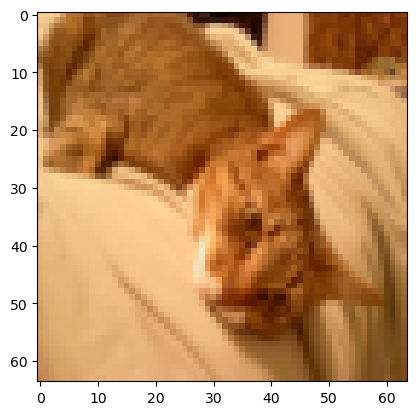

In [19]:
index = 26
plt.imshow(test_set_x[:,index].reshape((num_px, num_px, 3)))
print ("y = " + str(test_set_y[0,index]) + ", you predicted that it is a \"" + classes[int(d["Y_prediction_test"][0,index])].decode("utf-8") +  "\" picture.")

## 9.4 绘制损失

① 到目前为止，我们的程序算是完成了，但是，我们可以在后面加一点东西，比如画点图什么的。

② 跑一波出来的效果图是这样的，可以看到损失下降，它显示参数正在被学习。

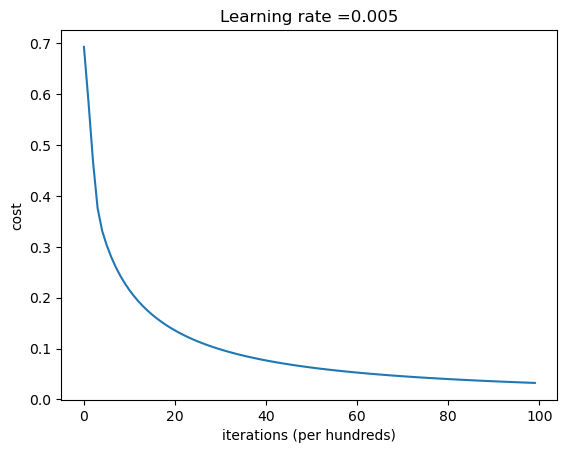

In [29]:
costs = np.squeeze(d['costs'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Learning rate =" + str(d["learning_rate"]))
plt.show()

## 9.5 迭代次数的选择

① 尝试增加上面单元格中的迭代次数，然后重新运行这些单元格。你可能会看到训练集准确性提高了，但是测试集准确性却降低了。这称为过度拟合。

② 我们以后会使用更好的算法来解决过拟合问题的。

## 9.6 学习率的选择

① 让我们进一步分析一下，并研究学习率的可能选择。

② 为了让渐变下降起作用，我们必须明智地选择学习速率。

③ 学习率 $\alpha$ 决定了我们更新参数的速度。
1. 如果学习率过高，我们可能会“超过”最优值。
2. 如果它太小，我们将需要太多迭代才能收敛到最佳值。

④ 这就是为什么使用良好调整的学习率至关重要的原因。

⑤ 我们可以比较一下我们模型的学习曲线和几种学习速率的选择。也可以尝试使用不同于我们初始化的learning_rates变量包含的三个值，并看一下会发生什么。

⑥ 解释：

1. 不同的学习率会带来不同的损失，因此会有不同的预测结果。
2. 如果学习率太大（0.01），则成本可能会上下波动。 它甚至可能会发散（尽管在此示例中，使用0.01最终仍会以较高的损失值获得收益）。
3. 较低的损失并不意味着模型效果很好。当训练精度比测试精度高很多时，就会发生过拟合情况。
4. 在深度学习中，我们通常建议你：
 - 选择好能最小化损失函数的学习率。
 - 如果模型过度拟合，请使用其他方法来减少过度拟合。 （我们将在后面的教程中讨论。）

learning rate is: 0.01
train accuracy: 99.52153110047847 %
test accuracy: 68.0 %

-------------------------------------------------------

learning rate is: 0.001
train accuracy: 88.99521531100478 %
test accuracy: 64.0 %

-------------------------------------------------------

learning rate is: 0.0001
train accuracy: 68.42105263157895 %
test accuracy: 36.0 %

-------------------------------------------------------



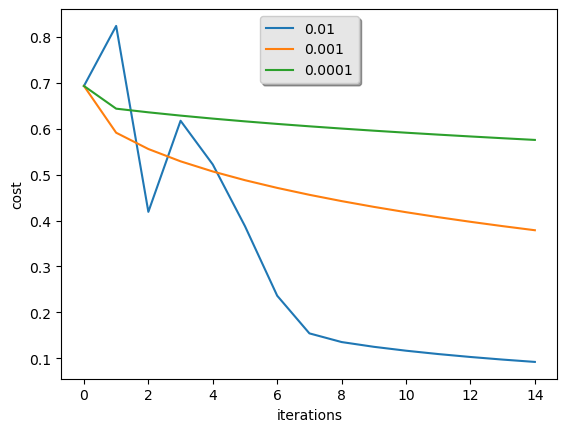

In [31]:
learning_rates = [0.01, 0.001, 0.0001]
models = {}
for i in learning_rates:
    print ("learning rate is: " + str(i))
    models[str(i)] = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations = 1500, learning_rate = i, print_cost = False)
    print ('\n' + "-------------------------------------------------------" + '\n')

for i in learning_rates:
    plt.plot(np.squeeze(models[str(i)]["costs"]), label= str(models[str(i)]["learning_rate"]))

plt.ylabel('cost')
plt.xlabel('iterations')

legend = plt.legend(loc='upper center', shadow=True)
frame = legend.get_frame()
frame.set_facecolor('0.90')
plt.show()